In [1]:
# Reads in FITS files from the MCT and checks them

In [47]:
from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval


%matplotlib inline

In [14]:
stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260331/'

In [20]:
subdir = 'up_the_ramp/20260331154153/'

In [21]:
file_name_list = glob.glob(stem + subdir + '*.fits')
file_name_list = sorted(file_name_list)

In [22]:
file_name_list 

['/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260331/up_the_ramp/20260331154153/H2RG_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260331/up_the_ramp/20260331154153/H2RG_R01_M01_N02.fits',
 '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260331/up_the_ramp/20260331154153/H2RG_R01_M01_N03.fits']

In [ ]:
# read in each 2D frame into a 3D cube

# read in a test frame to get the shape of the data
data_test = fits.open(file_name_list[0])[0].data

# make a 3D cube of the data
data_cube = np.zeros((len(file_name_list), data_test.shape[0], data_test.shape[1]))
for i, file_name in enumerate(file_name_list):
    hdul = fits.open(file_name)
    data_cube[i, :, :] = hdul[0].data

In [34]:
data_cube.shape

(3, 2048, 2048)

In [37]:
# make a linear fit to the pixels for each pixel in [:,:10,:10]

idx_frames = np.arange(len(file_name_list))
x = np.asarray(idx_frames)

size_window = 2048

Y2 = data_cube[:, :size_window, :size_window].reshape(len(x), -1)
A = np.vstack([x, np.ones_like(x)]).T
coeffs, _, _, _ = np.linalg.lstsq(A, Y2, rcond=None)
slopes = coeffs[0].reshape(size_window, size_window)
intercepts = coeffs[1].reshape(size_window, size_window)

'''
# x: independent variable, shape (n_frames,)
# y block: shape (n_frames, 10, 10)
Y = data_cube[:, :10, :10]
# flatten spatial dims -> shape (n_frames, 100)
Y2 = Y.reshape(len(x), -1)
x_mean = x.mean()
Y_mean = Y2.mean(axis=0)
slopes = ((x[:, None] - x_mean) * (Y2 - Y_mean)).sum(axis=0) / ((x - x_mean) ** 2).sum()
intercepts = Y_mean - slopes * x_mean
slopes = slopes.reshape(10, 10)
intercepts = intercepts.reshape(10, 10)
'''

'\n# x: independent variable, shape (n_frames,)\n# y block: shape (n_frames, 10, 10)\nY = data_cube[:, :10, :10]\n# flatten spatial dims -> shape (n_frames, 100)\nY2 = Y.reshape(len(x), -1)\nx_mean = x.mean()\nY_mean = Y2.mean(axis=0)\nslopes = ((x[:, None] - x_mean) * (Y2 - Y_mean)).sum(axis=0) / ((x - x_mean) ** 2).sum()\nintercepts = Y_mean - slopes * x_mean\nslopes = slopes.reshape(10, 10)\nintercepts = intercepts.reshape(10, 10)\n'

In [29]:
coeffs.shape

(2, 100)

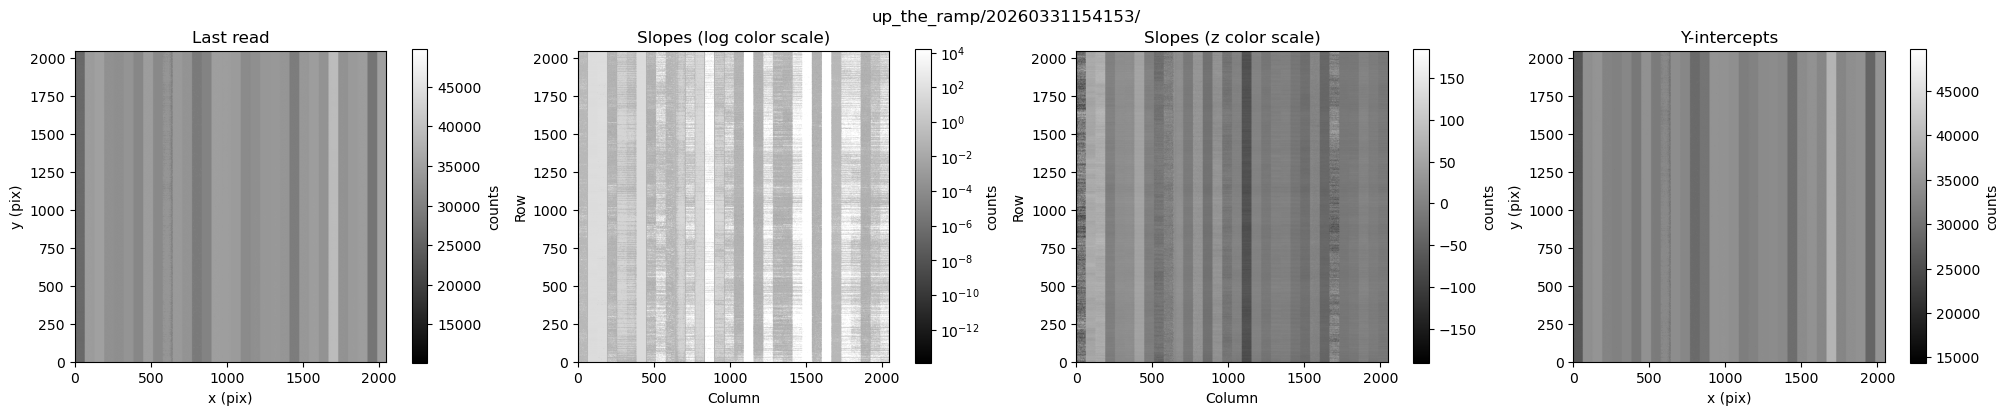

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
im0 = axs[0].imshow(data_cube[-1, :, :], origin='lower', cmap='gray')
axs[0].set_xlabel('x (pix)')
axs[0].set_ylabel('y (pix)')
axs[0].set_title('Last read in ramp')
fig.colorbar(im0, ax=axs[0], label='counts')

im1 = axs[1].imshow(slopes, origin='lower', cmap='gray', norm=LogNorm())
axs[1].set_xlabel('x (pix)')
axs[1].set_ylabel('y (pix)')
axs[1].set_xlabel('Column')
axs[1].set_ylabel('Row')
axs[1].set_title('Slopes (log color scale)')
fig.colorbar(im1, ax=axs[1], label='counts')

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(slopes)
im2 = axs[2].imshow(
    slopes,
    origin='lower',
    cmap='gray',
    vmin=vmin,
    vmax=vmax,
)
axs[2].set_xlabel('x (pix)')
axs[2].set_ylabel('y (pix)')
axs[2].set_xlabel('Column')
axs[2].set_ylabel('Row')
axs[2].set_title('Slopes (z color scale)')
fig.colorbar(im2, ax=axs[2], label='counts')

im3 = axs[3].imshow(intercepts, origin='lower', cmap='gray')
axs[3].set_xlabel('x (pix)')
axs[3].set_ylabel('y (pix)')
axs[3].set_title('Y-intercepts')
fig.colorbar(im3, ax=axs[3], label='counts')
plt.suptitle(subdir)
plt.show()

In [14]:
file_name_num = 0
for file_name in file_name_list:

    hdul = fits.open(file_name)
    data = hdul[0].data
    print(data.shape)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # First subplot: show the full image
    im0 = axs[0].imshow(data, origin='lower')
    axs[0].set_title('Full Image')
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    middle_row = data[data.shape[0] // 2, :]
    axs[1].plot(middle_row)
    axs[1].set_title('Middle Row Profile')
    axs[1].set_xlabel('Column')
    axs[1].set_ylabel('Value')

    central_col = data[:, data.shape[0] // 2]
    axs[2].plot(central_col)
    axs[2].set_title('Central col Profile')
    axs[2].set_xlabel('Row')
    axs[2].set_ylabel('Value')
    
    fig.suptitle(f"{file_name}\nmean: {np.mean(data):.2f}, std: {np.std(data):.2f}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    file_name_plot = f'junk_{file_name_num:02d}.png'
    plt.savefig(file_name_plot)
    plt.clf()
    file_name_num += 1


(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)
(2048, 2048)


<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

...

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

In [11]:

print(data.shape)
#plt.imshow(data, origin='lower')
#plt.show()

width_col = 64
n_cols = 32

# loop over the files
for file_name_num in range(0, len(file_name_list)):
    file_name = file_name_list[file_name_num]
    print(file_name)

    hdul = fits.open(file_name)
    frame_data = hdul[0].data

    # loop over each of the vertical readouts column, and subtract the median of that column
    for col_num in range(0, n_cols):
        idx1, idx2 = width_col*col_num, width_col*(col_num+1)
        col_data = frame_data[:, idx1:idx2]
        median_val = np.median(col_data)
        frame_data[:, idx1:idx2] = col_data - median_val
        #frame_data[:, idx1:idx2] = 0

        #print(col_num)
        #print(median_val)
        #print('--------------------------------')

        # plot the result
        #plt.imshow(frame_data, origin='lower')
        #plt.show()
    
    file_name_plot = 'frame_hot_' + str(file_name_num) + '.png'

    idx_hot = frame_data > np.std(frame_data)
    idx_normal = frame_data <= np.std(frame_data)
    pix_map = np.zeros_like(frame_data)
    # Compute a threshold for "hot" pixels using a robust statistic
    threshold = np.median(frame_data) + 5 * np.std(frame_data)
    pix_map = np.zeros_like(frame_data, dtype=np.uint8)
    pix_map[frame_data > threshold] = 0
    pix_map[frame_data < threshold] = 1

    plt.figure(figsize=(5, 5))
    plt.imshow(pix_map, origin='lower', cmap='gray')
    plt.title(f"Hot Pixel Map: {file_name_num}")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(file_name_plot, dpi=150)
    plt.close()
    print(f'Wrote {file_name_plot} ({np.sum(pix_map)} hot pixels)')



    '''
    file_name_plot = 'frame_data_' + str(file_name_num) + '.png'
    plt.figure(figsize=(5, 5))
    plt.imshow(frame_data, origin='lower')
    plt.savefig(file_name_plot)
    plt.clf()
    print('Wrote ' + file_name_plot)
    '''


(2048, 2048)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161526_R01_M01_N01.fits
Wrote frame_hot_0.png (4194304 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165058_R01_M01_N01.fits
Wrote frame_hot_1.png (4187421 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165250_R01_M01_N01.fits
Wrote frame_hot_2.png (4186198 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161516_R01_M01_N01.fits
Wrote frame_hot_3.png (4194304 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165304_R01_M01_N01.fits
Wrote frame_hot_4.png (4186419 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161153_R01_M01_N01.fits
Wrote frame_hot_5.png (4194304 hot pixels)
/Users/eckhartspalding/Docu

In [ ]:
print(2048/32)

64.0
